In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.api import VAR
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

np.random.seed(42)
n_obs = 1000

In [4]:
dates = pd.date_range('2021-01-01', periods=n_obs, freq='ME')
data = {
    "GDP": np.cumsum(np.random.normal(0, 1, n_obs)) + 100,
    "Unemployment": np.cumsum(np.random.normal(0, 0.5, n_obs)) + 5,
    "Inflation": np.cumsum(np.random.normal(0, 0.3, n_obs)) + 2,
    "Interest_Rate": np.cumsum(np.random.normal(0, 0.2, n_obs)) + 3
}
df = pd.DataFrame(data, index=dates)

model = VAR(df)
results = model.fit(4)

lag_order = results.k_ar  # 滞后阶数 这里是4
forecast = results.forecast(df.values[-lag_order:], steps=12)  # 取最后四行数据作为起始输入
forecast_index = pd.date_range(df.index[-1] + pd.DateOffset(1), periods=12, freq='ME')  # 生成未来12个月的月末日期
df_forecast = pd.DataFrame(forecast, index=forecast_index, columns=df.columns)

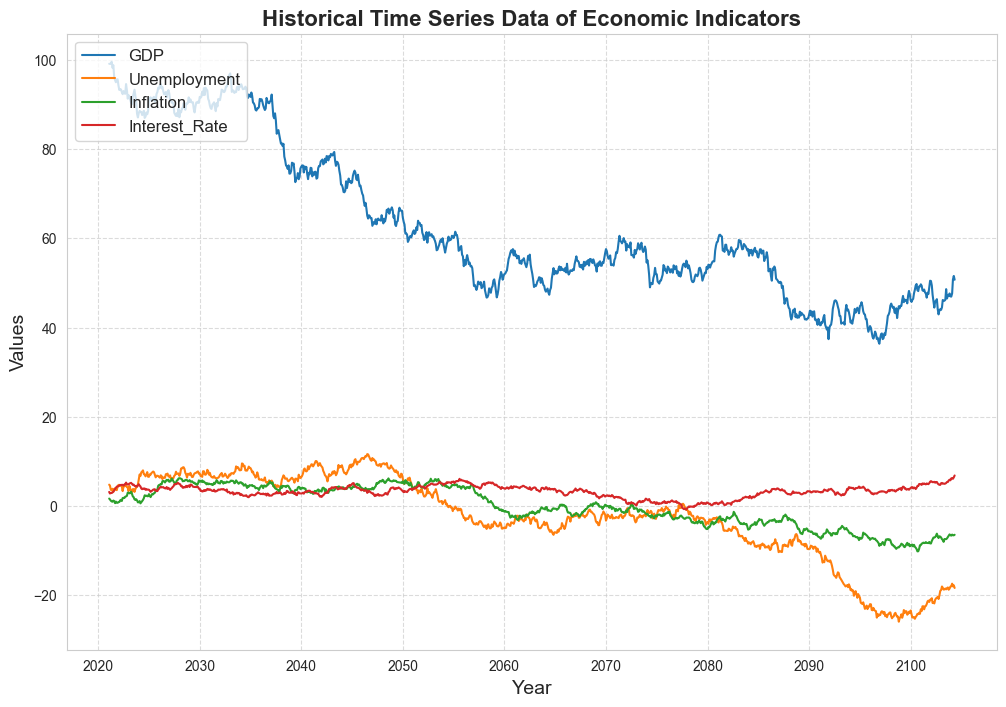

In [5]:
sns.set_style('whitegrid')

plt.figure(figsize=(12, 8))
for i, col in enumerate(df.columns):
    plt.plot(df.index, df[col], label=col, linewidth=1.5)
plt.legend(loc="upper left", fontsize=12)
plt.title("Historical Time Series Data of Economic Indicators", fontsize=16, weight="bold")
plt.xlabel("Year", fontsize=14)
plt.ylabel("Values", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

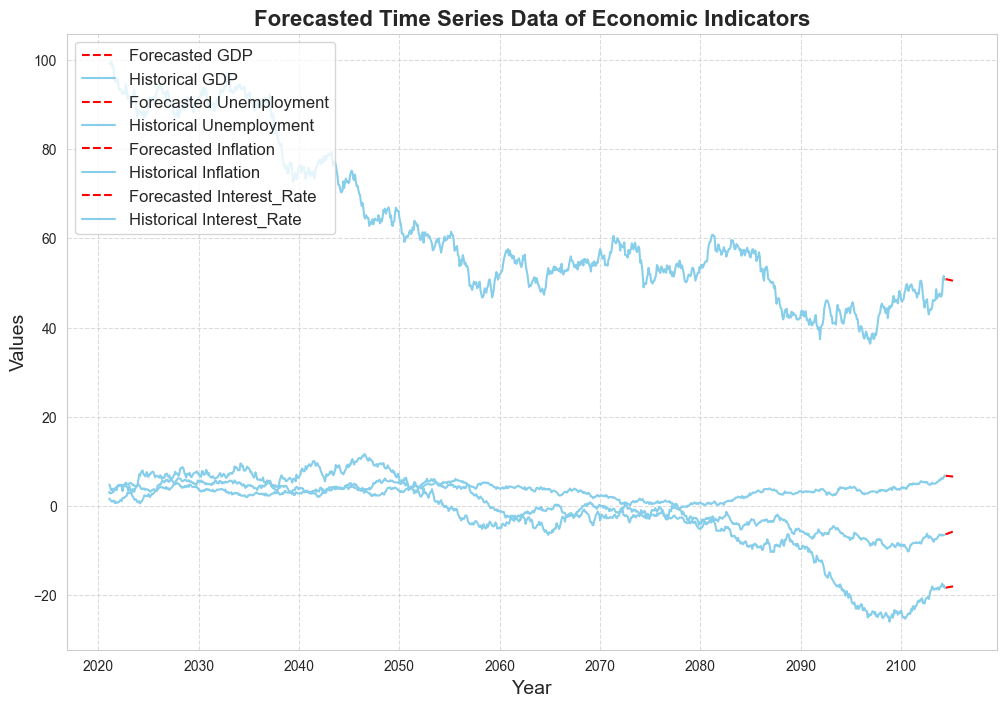

In [8]:
plt.figure(figsize=(12, 8))
for i, col in enumerate(df.columns):
    plt.plot(df_forecast.index, df_forecast[col], label=f"Forecasted {col}", linestyle='--', linewidth=1.5, color='red')
    plt.plot(df.index, df[col], label=f"Historical {col}", linewidth=1.5, color='skyblue')
plt.legend(loc="upper left", fontsize=12)
plt.title("Forecasted Time Series Data of Economic Indicators", fontsize=16, weight="bold")
plt.xlabel("Year", fontsize=14)
plt.ylabel("Values", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

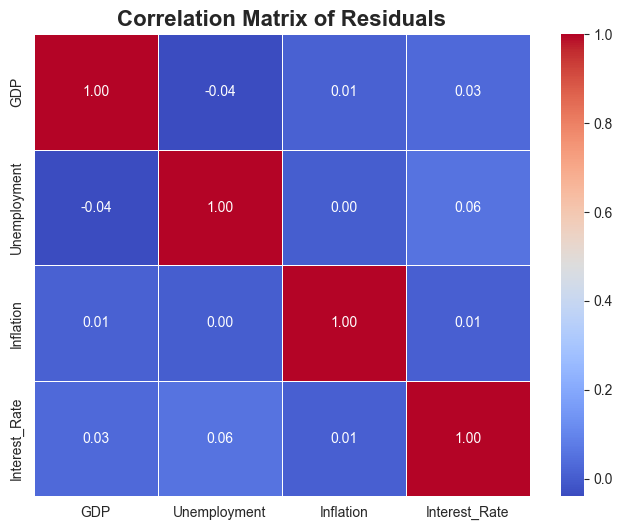

In [10]:
residuals = results.resid
plt.figure(figsize=(8, 6))
sns.heatmap(residuals.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Residuals', fontsize=16, weight='bold')
plt.show()

<Figure size 1000x400 with 0 Axes>

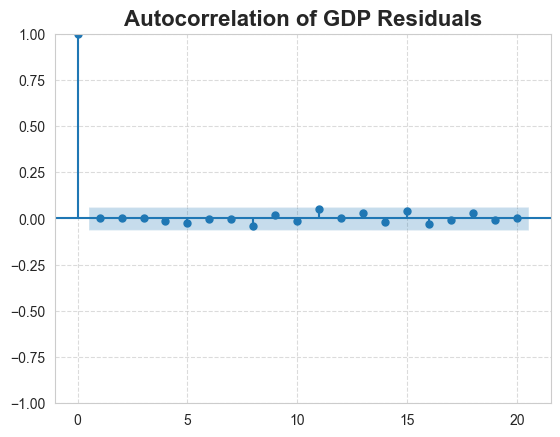

In [11]:
plt.figure(figsize=(10, 4))
plot_acf(residuals["GDP"], lags=20)
plt.title("Autocorrelation of GDP Residuals", fontsize=16, weight="bold")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

<Figure size 1000x400 with 0 Axes>

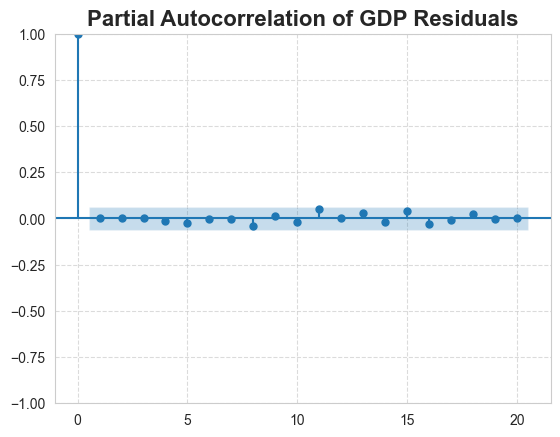

In [13]:
plt.figure(figsize=(10, 4))
plot_pacf(residuals["GDP"], lags=20)
plt.title("Partial Autocorrelation of GDP Residuals", fontsize=16, weight="bold")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()